In [4]:
# Data Analysis Capstone Project
# Applying data analysis techniques to Tesla stock dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('./TSLA.csv')

# Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Sort data by Date
data = data.sort_values('Date')

# Summary statistics for numeric columns
summary_stats = data.describe()
print("Summary Statistics:")
print(summary_stats)

Summary Statistics:
                                Date         Open         High          Low  \
count                           2956  2956.000000  2956.000000  2956.000000   
mean   2016-05-11 07:21:21.190798336   138.691296   141.771603   135.425953   
min              2010-06-29 00:00:00     3.228000     3.326000     2.996000   
25%              2013-06-05 18:00:00    19.627000    20.402000    19.127500   
50%              2016-05-11 12:00:00    46.656999    47.487001    45.820002   
75%              2019-04-19 00:00:00    68.057001    69.357500    66.911501   
max              2022-03-24 00:00:00  1234.410034  1243.489990  1217.000000   
std                              NaN   250.044839   255.863239   243.774157   

             Close    Adj Close        Volume  
count  2956.000000  2956.000000  2.956000e+03  
mean    138.762183   138.762183  3.131449e+07  
min       3.160000     3.160000  5.925000e+05  
25%      19.615000    19.615000  1.310288e+07  
50%      46.545000    46.545

In [5]:
# Adding calculated columns
# 1. Daily Price Change
data['Daily_Change'] = data['High'] - data['Low']

# 2. Daily Return (percentage change in Close price)
data['Daily_Return'] = data['Close'].pct_change() * 100

# 3. Moving Averages (50-day and 200-day)
data['50_MA'] = data['Close'].rolling(window=50).mean()
data['200_MA'] = data['Close'].rolling(window=200).mean()

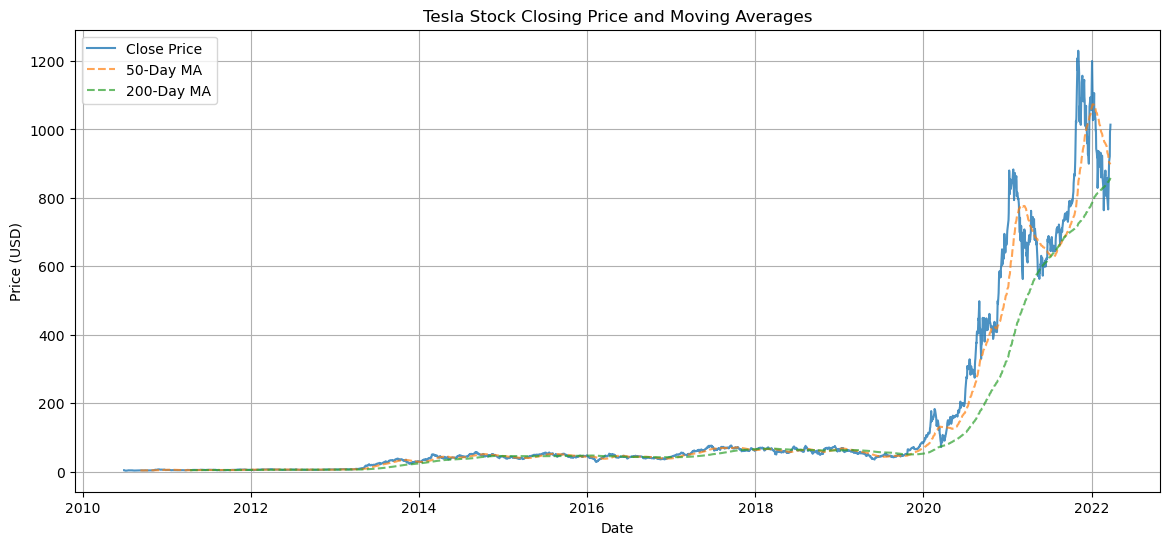

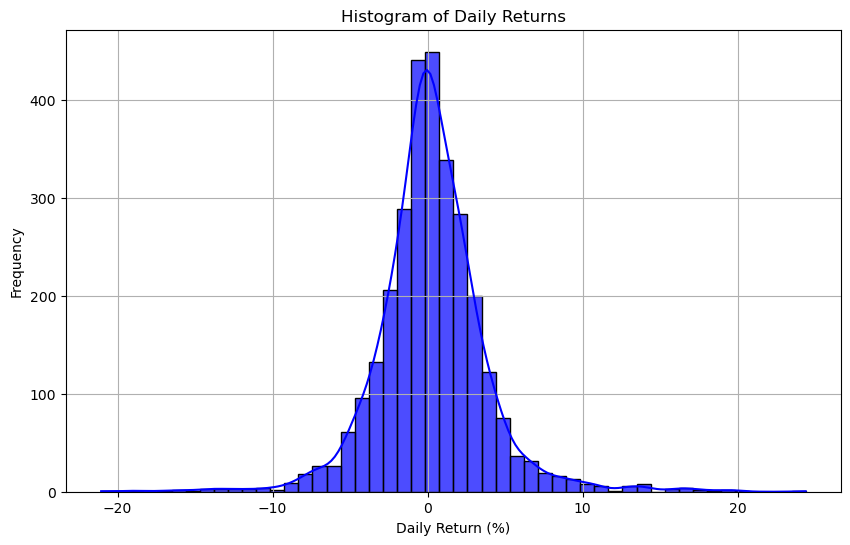

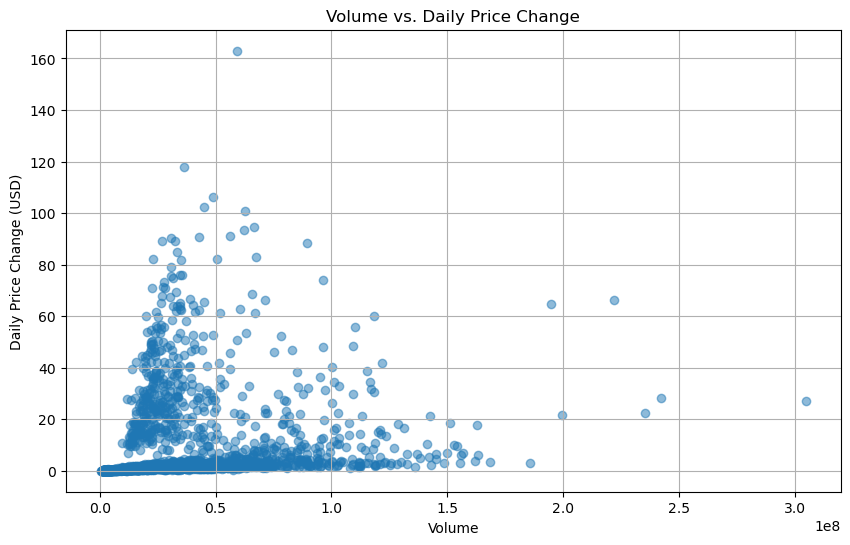

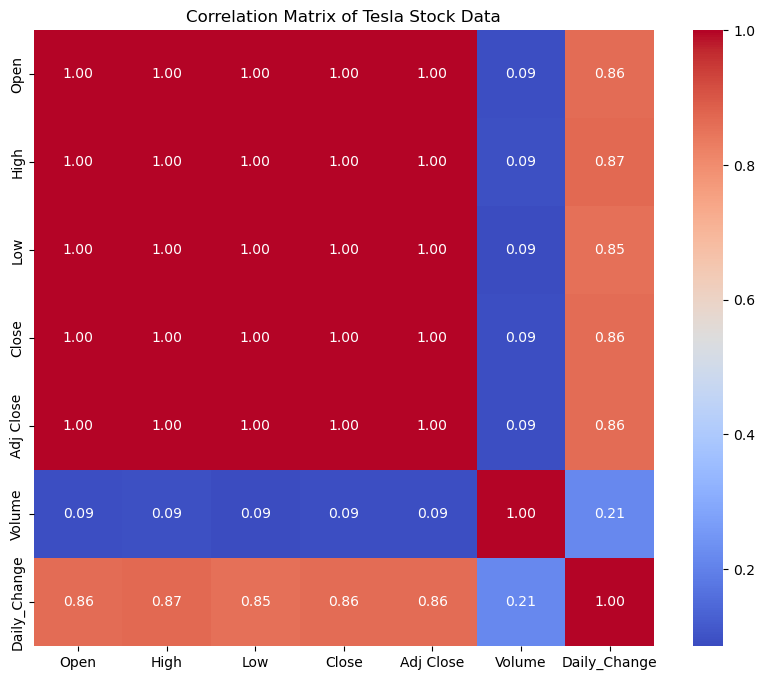

In [6]:
# Data Analysis and Visualization
# Plot closing price and moving averages
plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', alpha=0.8)
plt.plot(data['Date'], data['50_MA'], label='50-Day MA', linestyle='--', alpha=0.7)
plt.plot(data['Date'], data['200_MA'], label='200-Day MA', linestyle='--', alpha=0.7)
plt.title('Tesla Stock Closing Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

# Histogram of daily returns
plt.figure(figsize=(10, 6))
sns.histplot(data['Daily_Return'].dropna(), bins=50, kde=True, color='blue', alpha=0.7)
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

# Scatter plot of Volume vs. Daily Change
plt.figure(figsize=(10, 6))
plt.scatter(data['Volume'], data['Daily_Change'], alpha=0.5)
plt.title('Volume vs. Daily Price Change')
plt.xlabel('Volume')
plt.ylabel('Daily Price Change (USD)')
plt.grid()
plt.show()

# Correlation heatmap
correlation_matrix = data[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Change']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Tesla Stock Data')
plt.show()

# Summary of Findings
# - Visualize trends, distributions, and relationships in the dataset
# - Analyze correlations to uncover insights, such as how volume relates to price changes
# - Use moving averages to identify long-term trends